In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    "../data/processed/feature_matrix.csv"
)

print(df.shape)

df.head()

(4964, 7)


,lat,lon,mean_annual_rf,std_annual,cv,dry_days,heavy_days
0,8.25,77.00,1368.70980,409.68338,0.299321,253.051282,0.487179
1,8.25,77.25,1163.10000,317.94876,0.273363,265.871795,0.487179
2,8.25,77.50,749.88873,343.41086,0.457949,313.076923,0.282051
3,8.25,77.75,758.49920,328.97153,0.433714,294.102564,0.256410
4,8.50,76.75,1833.17690,363.57733,0.198332,233.205128,0.820513


In [4]:
df.describe()

,lat,lon,mean_annual_rf,std_annual,cv,dry_days,heavy_days
count,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000,4964.000000
mean,23.612460,79.459962,1149.826189,347.673409,0.348033,282.997650,0.697101
std,6.039214,6.033288,739.382573,239.795880,0.305075,36.735543,1.276794
min,8.250000,68.000000,23.241503,84.413190,0.127652,161.076923,0.000000
25%,19.750000,75.250000,696.895880,231.230430,0.241824,262.871795,0.153846
50%,24.000000,78.250000,988.503200,285.327770,0.290125,289.320513,0.435897
75%,27.250000,82.250000,1337.710075,374.513550,0.377093,307.333333,0.769231
max,37.250000,97.250000,9444.708000,3785.033000,6.164414,363.076923,28.128205


In [5]:
def minmax(series):

    return (
        series - series.min()
    ) / (
        series.max() - series.min() + 1e-8
    )

In [6]:
df["rf_norm"] = minmax(
    df["mean_annual_rf"]
)

In [7]:
df["cv_norm"] = 1 - minmax(
    df["cv"]
)

In [8]:
df["dry_norm"] = 1 - minmax(
    df["dry_days"]
)

In [9]:
df["heavy_norm"] = 1 - minmax(
    df["heavy_days"]
)

Cell 6 - Build SCRI

Simple weighted index:

In [10]:
df["scri"] = (
      0.30 * df["rf_norm"]
    + 0.25 * df["cv_norm"]
    + 0.20 * df["dry_norm"]
    + 0.25 * df["heavy_norm"]
)

In [11]:
df["scri"].describe()

count    4964.000000
mean        0.599837
std         0.057292
min         0.250000
25%         0.564288
50%         0.592863
75%         0.630341
max         0.785535
Name: scri, dtype: float64

In [12]:
df["risk_tier"] = pd.cut(
    df["scri"],
    bins=[0,0.40,0.55,0.70,1.0],
    labels=[
        "Critical",
        "High",
        "Moderate",
        "Low"
    ]
)

SCRI < 0.40
Very poor resilience

0.40–0.55
Weak resilience

0.55–0.70
Moderate resilience

 >0.70
Strong resilience

In [13]:
df["risk_tier"].value_counts()

risk_tier
Moderate    3776
High         815
Low          363
Critical      10
Name: count, dtype: int64

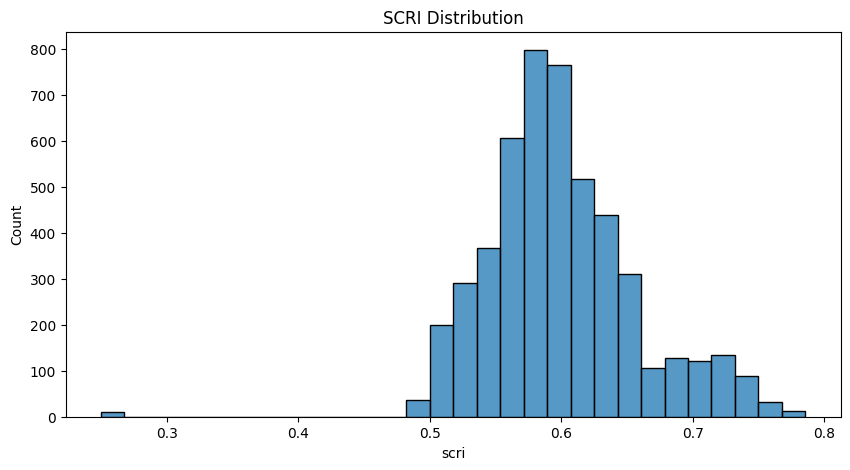

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["scri"],
    bins=30
)

plt.title(
    "SCRI Distribution"
)

plt.show()

India SCRI Map ⭐

In [ ]:
plt.figure(figsize=(12,8))

plt.scatter(
    df["lon"],
    df["lat"],
    c=df["scri"],
    cmap="RdYlGn",
    s=10
)

plt.colorbar(
    label="SCRI"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Sponge City Readiness Index"
)

plt.show()

RISK TIERS MAP

In [ ]:
risk_colors = {
    "Critical":"red",
    "High":"orange",
    "Moderate":"yellow",
    "Low":"green"
}

plt.figure(figsize=(12,8))

for tier in risk_colors:

    subset = df[
        df["risk_tier"] == tier
    ]

    plt.scatter(
        subset["lon"],
        subset["lat"],
        s=8,
        color=risk_colors[tier],
        label=tier
    )

plt.legend()

plt.title(
    "SCRI Risk Categories"
)

plt.show()

In [17]:
df.to_csv(
    "../data/processed/scri_scores.csv",
    index=False
)

print("SCRI saved.")

SCRI saved.


In [18]:
df["risk_tier"].value_counts()

risk_tier
Moderate    3776
High         815
Low          363
Critical      10
Name: count, dtype: int64

2nd type Z type

In [20]:
pip install jenkspy

Note: you may need to restart the kernel to use updated packages.


In [19]:
df["scri_z"] = (
    df["scri"] - df["scri"].mean()
) / df["scri"].std()

In [20]:
conditions = [
    df["scri_z"] <= -1,
    (df["scri_z"] > -1) & (df["scri_z"] <= 0),
    (df["scri_z"] > 0) & (df["scri_z"] <= 1),
    df["scri_z"] > 1
]

labels = [
    "Low",
    "Moderate",
    "High",
    "Critical"
]

df["risk_tier"] = np.select(
    conditions,
    labels
)

In [ ]:
plt.figure(figsize=(12,8))

plt.scatter(
    df["lon"],
    df["lat"],
    c=df["scri"],
    cmap="RdYlGn",
    s=10
)

plt.colorbar(
    label="SCRI"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Sponge City Readiness Index"
)

plt.show()

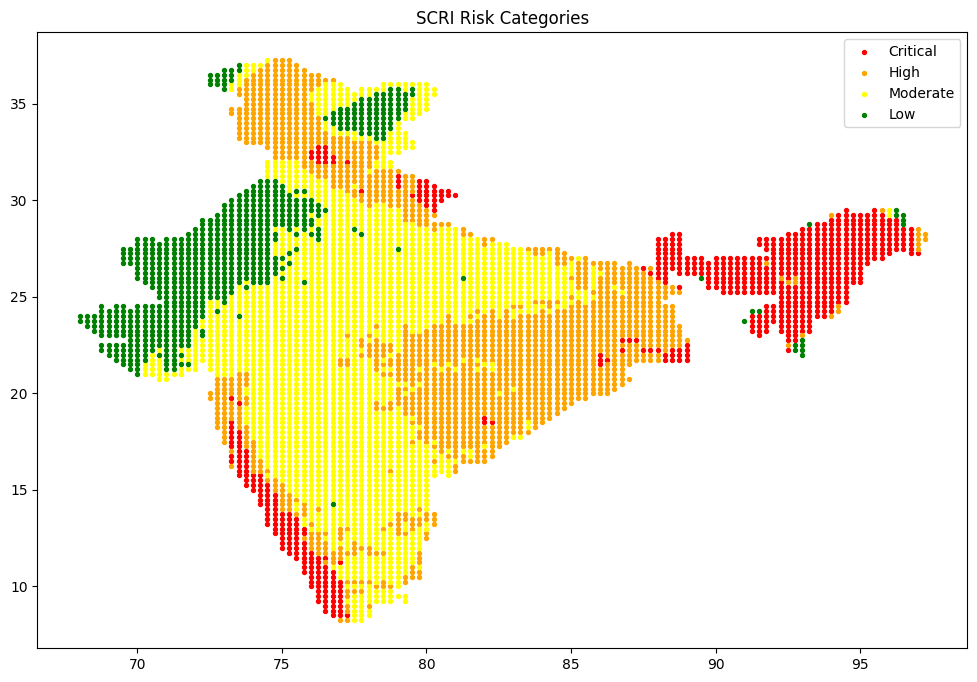

In [22]:
risk_colors = {
    "Critical":"red",
    "High":"orange",
    "Moderate":"yellow",
    "Low":"green"
}

plt.figure(figsize=(12,8))

for tier in risk_colors:

    subset = df[
        df["risk_tier"] == tier
    ]

    plt.scatter(
        subset["lon"],
        subset["lat"],
        s=8,
        color=risk_colors[tier],
        label=tier
    )

plt.legend()

plt.title(
    "SCRI Risk Categories"
)

plt.show()

In [23]:
df.to_csv(
    "../data/processed/scri_dataset.csv",
    index=False
)